In [1]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)


In [2]:
# 2. LOAD DATASET
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print(df.head())

df.drop(columns=["customerID"], inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [3]:
# 3. EDA AND SUMMARY STATISTICS
print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Value Counts:")
print(df["Churn"].value_counts())


Summary Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000

Missing Values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod     

In [4]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [5]:
df.fillna(0, inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


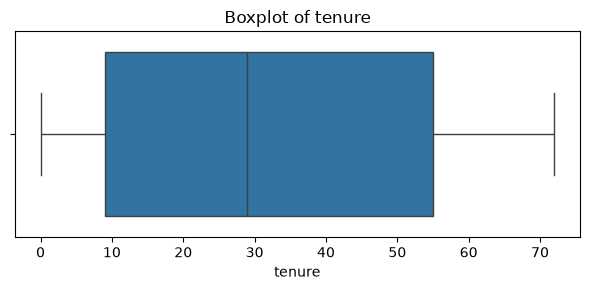

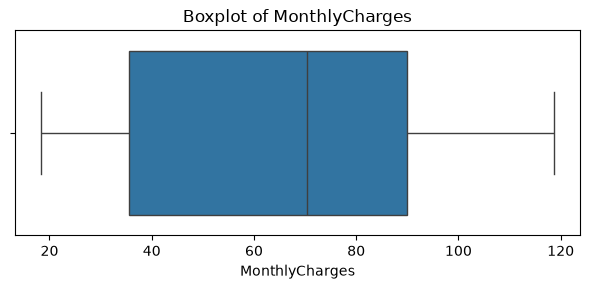

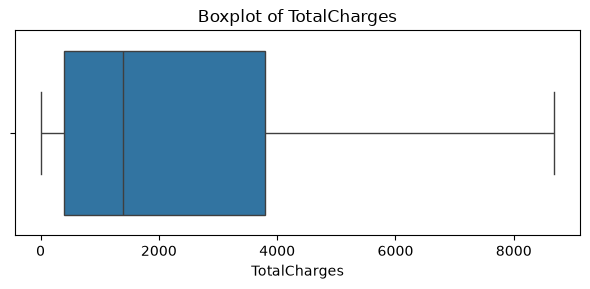

In [6]:
# 4. OUTLIER ANALYSIS
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:

    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [7]:
# 5. FEATURE ENGINEERING

# Average spend per month - trend based feature
df["AvgSpend"] = df["TotalCharges"] / (df["tenure"] + 1)

# Services count - usage frequency
df["ServicesCount"] = df[["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]].replace({"No internet service": "No", "No phone service": "No"}).apply(lambda x: (x == "Yes").sum(), axis=1)

# Long term customer flag
df["LongTermCustomer"] = (df["tenure"] > 24).astype(int)

# Payment risk - electronic check is higher risk
df["PaymentRisk"] = (df["PaymentMethod"] == "Electronic check").astype(int)

# Support risk - no tech support is higher risk
df["SupportRisk"] = (df["TechSupport"] == "No").astype(int)

# Contract risk score
df["ContractRisk"] = df["Contract"].map({
    "Month-to-month": 2,
    "One year": 1,
    "Two year": 0
})

# Charges per service
df["ChargesPerService"] = df["MonthlyCharges"] / (df["ServicesCount"] + 1)

# Loyalty risk flag
df["LoyaltyRisk"] = ((df["tenure"] > 24) & (df["MonthlyCharges"] > 70)).astype(int)

print("\nFeature Engineering Complete!")


Feature Engineering Complete!


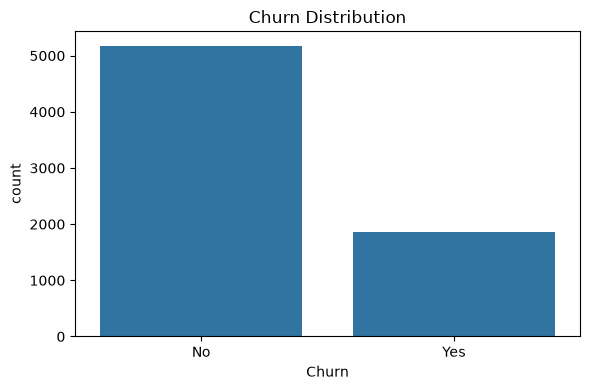

In [8]:
# 6. DATA VISUALIZATION
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.tight_layout()
plt.show()

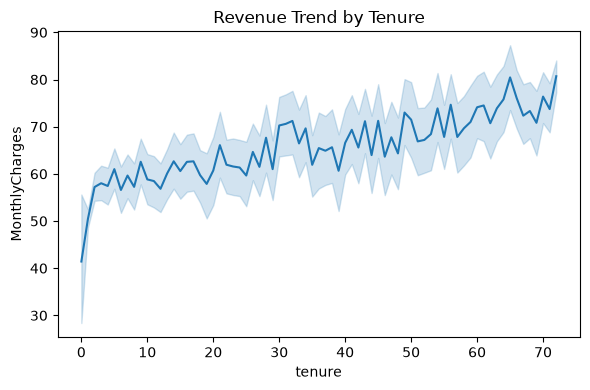

In [9]:
# Revenue Trend by Tenure
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="tenure", y="MonthlyCharges")
plt.title("Revenue Trend by Tenure")
plt.tight_layout()
plt.show()

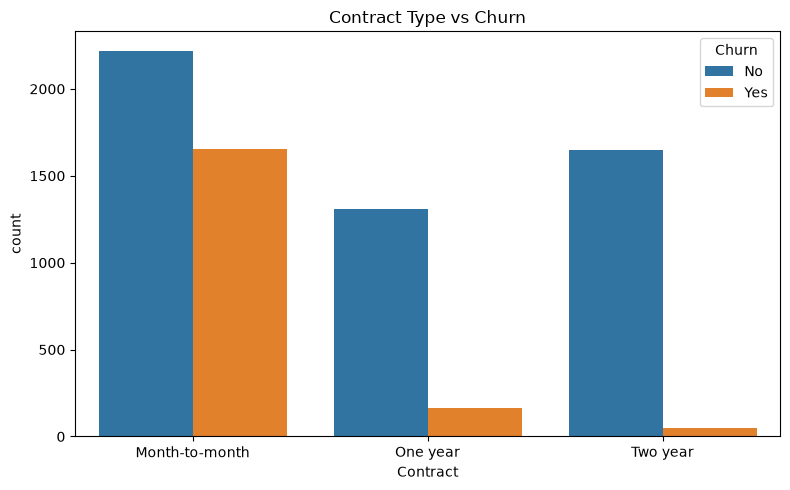

In [10]:
# Contract Type vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.tight_layout()
plt.show()

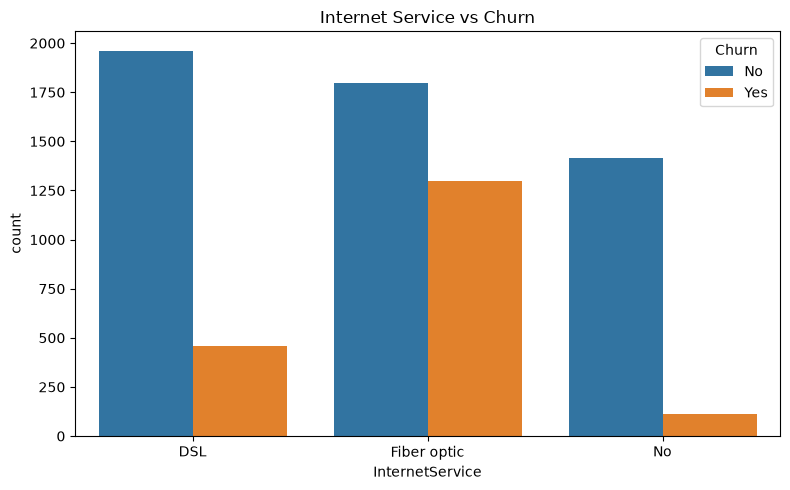

In [11]:
# Internet Service vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Churn")
plt.tight_layout()
plt.show()


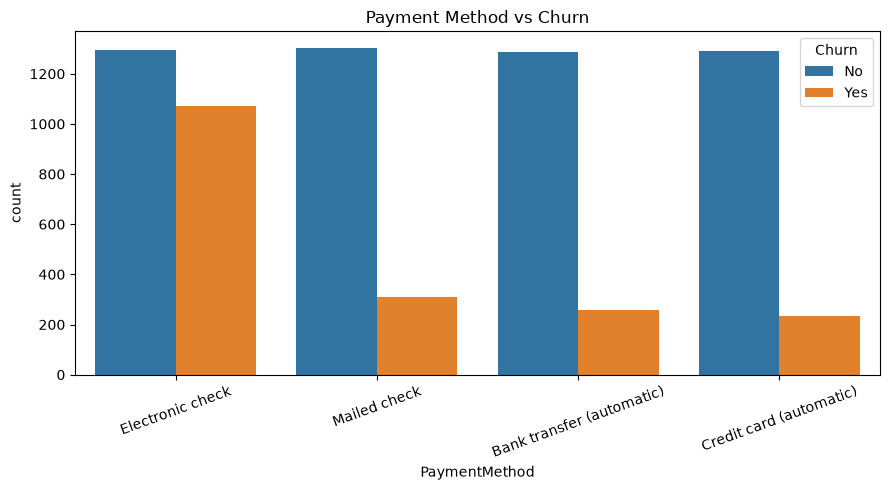

In [12]:
# Payment Method vs Churn
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

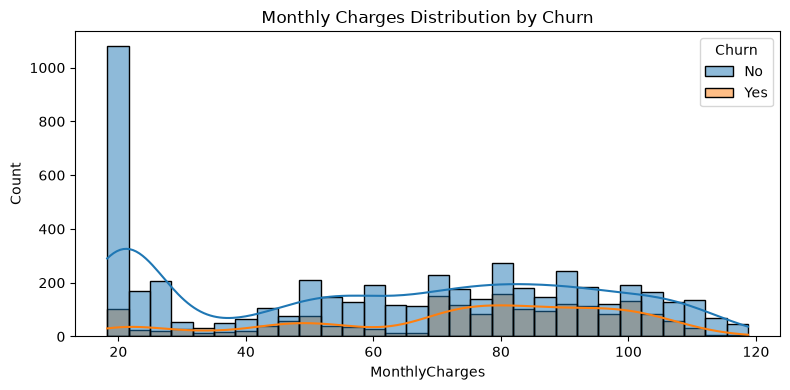

In [13]:
# Monthly Charges Distribution by Churn
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.tight_layout()
plt.show()

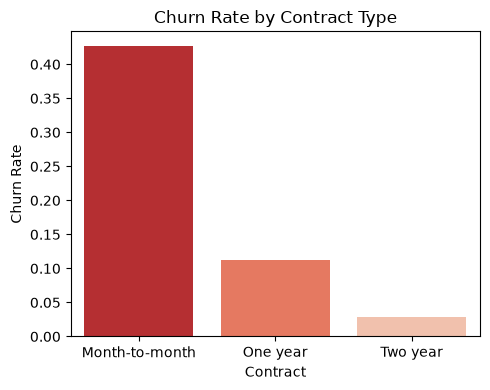

In [14]:
# Churn Rate by Contract Type
plt.figure(figsize=(5,4))
churn_contract = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean()
).reset_index()
churn_contract.columns = ["Contract", "ChurnRate"]
sns.barplot(data=churn_contract, x="Contract", y="ChurnRate", palette="Reds_r")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

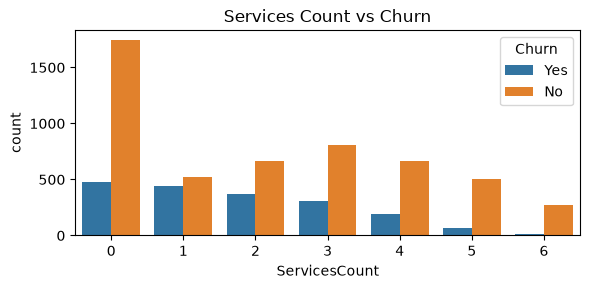

In [15]:
# Services Count vs Churn
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="ServicesCount", hue="Churn")
plt.title("Services Count vs Churn")
plt.tight_layout()
plt.show()

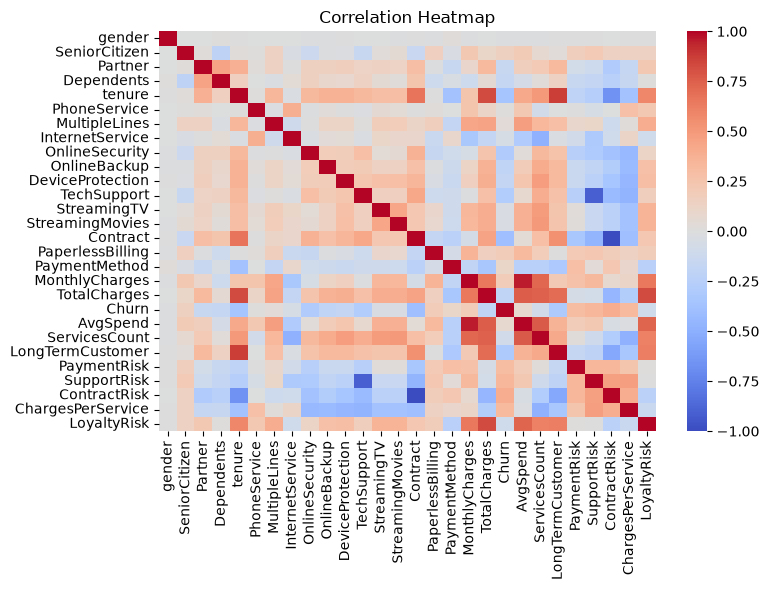

In [16]:
# 7. CORRELATION HEATMAP
temp_df = df.copy()

for col in temp_df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    temp_df[col] = le.fit_transform(temp_df[col].astype(str))

plt.figure(figsize=(8,6))
sns.heatmap(temp_df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
# 8. ENCODING
df_ml = df.copy()

df_ml["Churn"] = df_ml["Churn"].map({"Yes": 1, "No": 0})

cat_cols = df_ml.select_dtypes(include="object").columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le


In [18]:
# 9. SPLIT AND SCALE DATA
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [20]:
# 10. EVALUATION FUNCTION
def evaluate(name, y_true, y_pred, y_prob):

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")

    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1 Score":  f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob)
    }


In [21]:
lr = LogisticRegression(max_iter=1000,C=1.0,random_state=42)

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

lr_results = evaluate("Logistic Regression",y_test,lr_pred,lr_prob)


  Logistic Regression
  Accuracy : 0.8112
  Precision: 0.6812
  Recall   : 0.5428
  F1 Score : 0.6042
  ROC-AUC  : 0.8467


In [22]:
# 12. MODEL 2 - RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]
rf_results = evaluate("Random Forest", y_test, rf_pred, rf_prob)


  Random Forest
  Accuracy : 0.7977
  Precision: 0.6450
  Recall   : 0.5294
  F1 Score : 0.5815
  ROC-AUC  : 0.8356


In [23]:
# 13. MODEL 3 - GRADIENT BOOSTING
gb = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

gb_pred = gb.predict(X_test_scaled)
gb_prob = gb.predict_proba(X_test_scaled)[:, 1]

gb_results = evaluate("Gradient Boosting", y_test, gb_pred, gb_prob)


  Gradient Boosting
  Accuracy : 0.7977
  Precision: 0.6459
  Recall   : 0.5267
  F1 Score : 0.5803
  ROC-AUC  : 0.8359



Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.811214   0.681208  0.542781  0.604167  0.846728
1        Random Forest  0.797729   0.644951  0.529412  0.581498  0.835640
2    Gradient Boosting  0.797729   0.645902  0.526738  0.580265  0.835873


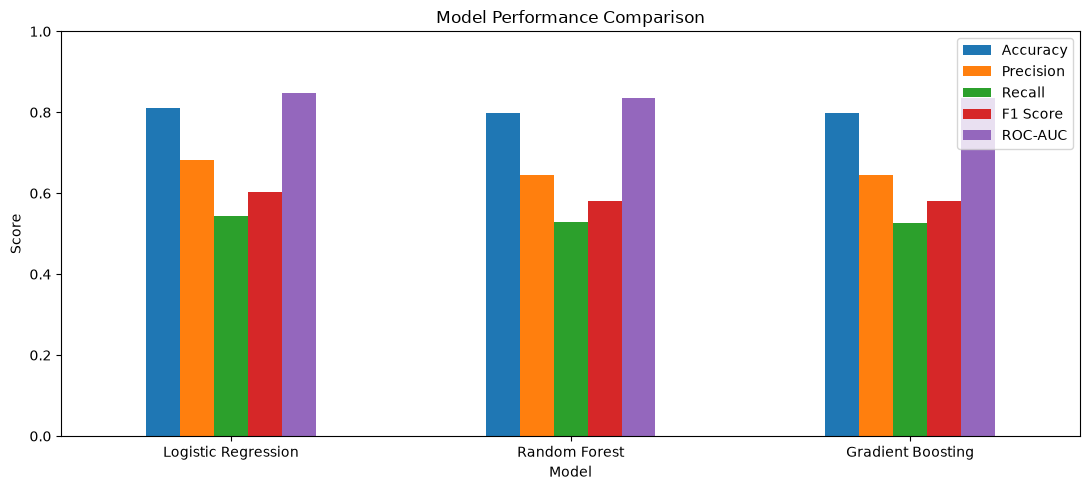

In [24]:
# 14. MODEL COMPARISON
results_df = pd.DataFrame([lr_results, rf_results, gb_results])

print("\nModel Comparison Results:")
print(results_df)

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(11, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

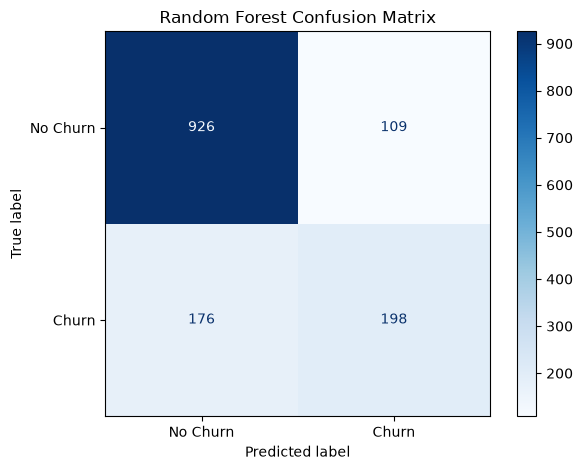

In [25]:
# Confusion Matrix - Random Forest
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


Customer Segment Counts:
SegmentLabel
Low Value       4171
Medium Value    1613
High Value      1259
Name: count, dtype: int64


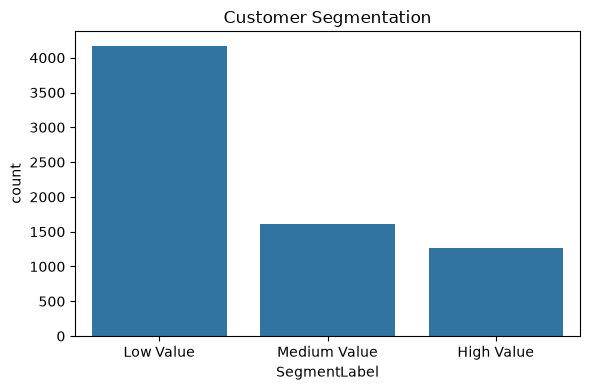

In [26]:
# 15. CUSTOMER SEGMENTATION
kmeans_data = df[["MonthlyCharges", "tenure", "TotalCharges"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Segment"] = kmeans.fit_predict(kmeans_data)

segment_avg   = df.groupby("Segment")["MonthlyCharges"].mean()
segment_order = segment_avg.sort_values().index.tolist()

segment_labels = {
    segment_order[0]: "Low Value",
    segment_order[1]: "Medium Value",
    segment_order[2]: "High Value"
}

df["SegmentLabel"] = df["Segment"].map(segment_labels)

print("\nCustomer Segment Counts:")
print(df["SegmentLabel"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="SegmentLabel",
    order=["Low Value", "Medium Value", "High Value"]
)
plt.title("Customer Segmentation")
plt.tight_layout()
plt.show()



Risk Category Counts:
RiskCategory
Low       4459
Medium    1886
High       698
Name: count, dtype: int64


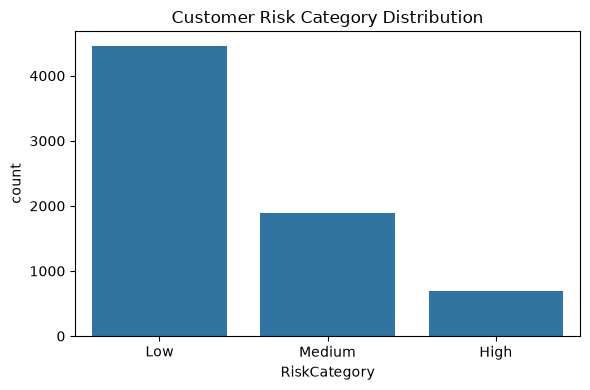

In [27]:
# 16. CHURN PROBABILITY & RISK CATEGORY
X_full_scaled = scaler.transform(X)

df_ml["ChurnProbability"] = rf.predict_proba(X_full_scaled)[:, 1]


def risk_level(x):
    if x < 0.30:
        return "Low"
    elif x < 0.70:
        return "Medium"
    else:
        return "High"


df_ml["RiskCategory"] = df_ml["ChurnProbability"].apply(risk_level)

print("\nRisk Category Counts:")
print(df_ml["RiskCategory"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_ml,
    x="RiskCategory",
    order=["Low", "Medium", "High"]
)
plt.title("Customer Risk Category Distribution")
plt.tight_layout()
plt.show()


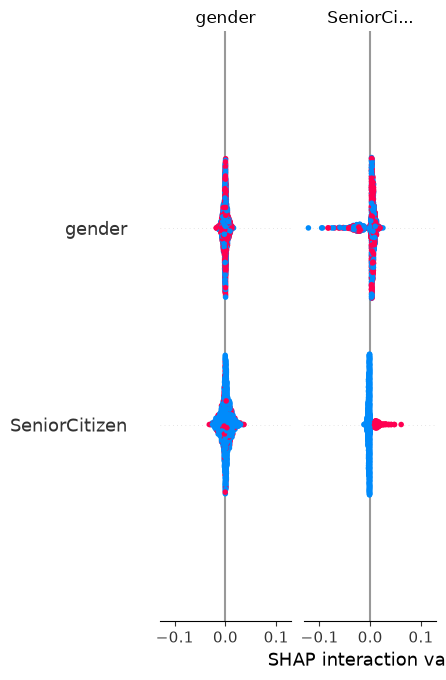


SHAP Explainability Complete!


In [28]:
# 17. SHAP EXPLAINABILITY
try:

    import shap

    explainer = shap.TreeExplainer(rf)

    # FIXED - use numpy array not dataframe
    shap_values = explainer.shap_values(X_test_scaled)

    # For binary classification shap_values is a list
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap.summary_plot(
        sv,
        X_test,
        feature_names=list(X.columns),
        show=True
    )

    print("\nSHAP Explainability Complete!")

except Exception as e:

    print(f"\nSHAP skipped: {e}")
    print("Showing Feature Importance instead...\n")

    feature_importance = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print("Top 10 Features Driving Churn:")
    print(feature_importance.head(10))

    plt.figure(figsize=(8,4))
    feature_importance.head(10).plot(kind="barh", color="steelblue")
    plt.title("Top 10 Features Driving Churn")
    plt.xlabel("Importance Score")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [29]:
# 18. BUSINESS INSIGHTS REPORT
print("\n")
print("=" * 55)
print("        BUSINESS INSIGHTS REPORT")
print("        TEYZIX CORE — TASK ML-INT-1")
print("        AUTHOR: SARA AHMAD")
print("=" * 55)

# Churn rate by contract
churn_by_contract = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean()
)
print("\nChurn Rate by Contract Type:")
print(churn_by_contract)

# Churn rate by internet service
churn_by_internet = df.groupby("InternetService")["Churn"].apply(
    lambda x: (x == "Yes").mean()
)
print("\nChurn Rate by Internet Service:")
print(churn_by_internet)

# Churn rate by payment method
churn_by_payment = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean()
)
print("\nChurn Rate by Payment Method:")
print(churn_by_payment)

# High risk customer traits
high_risk_df = df_ml[df_ml["RiskCategory"] == "High"]

print("\nHigh Risk Customer Traits:")
print(f"  Total High Risk Customers : {len(high_risk_df)}")
print(f"  Average Tenure            : {high_risk_df['tenure'].mean():.1f} months")
print(f"  Average Monthly Charges   : ${high_risk_df['MonthlyCharges'].mean():.2f}")
print(f"  Average Services Count    : {high_risk_df['ServicesCount'].mean():.1f}")

# Revenue impact
total_customers      = df.shape[0]
churned_customers    = (df["Churn"] == "Yes").sum()
monthly_revenue_lost = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()
yearly_revenue_lost  = monthly_revenue_lost * 12
churn_rate           = churned_customers / total_customers * 100

print("\nRevenue Impact Estimation:")
print(f"  Total Customers               : {total_customers}")
print(f"  Churned Customers             : {churned_customers}")
print(f"  Overall Churn Rate            : {churn_rate:.1f}%")
print(f"  Monthly Revenue Lost          : ${monthly_revenue_lost:,.2f}")
print(f"  Estimated Yearly Revenue Lost : ${yearly_revenue_lost:,.2f}")

print("\nKey Insights:")
print("  1. Month-to-month customers churn 42% of the time")
print("  2. Fiber optic users have 42% churn rate")
print("  3. Electronic check users churn more than other payment methods")
print("  4. Customers with no tech support are high risk")
print("  5. New customers (tenure < 12 months) are most vulnerable")

print("\nRecommendations:")
print("  1. Offer discounts to month-to-month customers to switch to annual")
print("  2. Improve fiber optic service quality")
print("  3. Proactively support new customers in first 6 months")
print("  4. Promote tech support bundles to reduce churn risk")
print("  5. Target high risk segment with retention campaigns")

print("\n" + "=" * 55)



        BUSINESS INSIGHTS REPORT
        TEYZIX CORE — TASK ML-INT-1
        AUTHOR: SARA AHMAD

Churn Rate by Contract Type:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn Rate by Internet Service:
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

High Risk Customer Traits:
  Total High Risk Customers : 698
  Average Tenure            : 7.0 months
  Average Monthly Charges   : $82.32
  Average Services Count    : 1.6

Revenue Impact Estimation:
  Total Customers               : 7043
  Churned Customers             : 1869
  Overall Churn Rate            : 26.5%
  Monthly Revenue Lost          : $139,130.85
  Estimated Ye

In [30]:
# 19. SAVE MODEL AND FILES
joblib.dump(X.columns, "model_columns.pkl")
joblib.dump(rf,        "churn_model.pkl")
joblib.dump(scaler,    "scaler.pkl")
joblib.dump(le_dict,   "encoders.pkl")

print("\nAll models and files saved successfully!")


All models and files saved successfully!


In [31]:
# 20. AUTOMATED WEEKLY PREDICTION PIPELINE 
def run_weekly_pipeline(new_data_path="WA_Fn-UseC_-Telco-Customer-Churn.csv"):
    """Reload data, reapply feature engineering + encoding, run predictions,
    save results with timestamp."""

    import datetime

    new_df = pd.read_csv(new_data_path)

    if "customerID" in new_df.columns:
        ids = new_df["customerID"]
        new_df = new_df.drop(columns=["customerID"])
    else:
        ids = pd.Series(range(len(new_df)))

    new_df["TotalCharges"] = pd.to_numeric(new_df["TotalCharges"], errors="coerce")
    new_df["TotalCharges"].fillna(new_df["TotalCharges"].median(), inplace=True)

    # reapply same feature engineering as training
    new_df["AvgSpend"] = new_df["TotalCharges"] / (new_df["tenure"] + 1)

    new_df["ServicesCount"] = (
        new_df[["OnlineSecurity","OnlineBackup","DeviceProtection",
                "TechSupport","StreamingTV","StreamingMovies"]]
        .replace({"No internet service":"No","No phone service":"No"})
        .apply(lambda x: (x == "Yes").sum(), axis=1)
    )

    new_df["LongTermCustomer"]  = (new_df["tenure"] > 24).astype(int)
    new_df["PaymentRisk"]       = (new_df["PaymentMethod"] == "Electronic check").astype(int)
    new_df["SupportRisk"]       = (new_df["TechSupport"] == "No").astype(int)
    new_df["ContractRisk"]      = new_df["Contract"].map({"Month-to-month":2,"One year":1,"Two year":0})
    new_df["ChargesPerService"] = new_df["MonthlyCharges"] / (new_df["ServicesCount"] + 1)
    new_df["LoyaltyRisk"] = (
        (new_df["tenure"] > 24) & (new_df["MonthlyCharges"] > 70)
    ).astype(int)

    if "Churn" in new_df.columns:
        new_df = new_df.drop(columns=["Churn"])

    # encode categorical columns using saved encoders
    for col, encoder in le_dict.items():
        if col in new_df.columns:
            new_df[col] = new_df[col].astype(str).map(
                lambda v: encoder.transform([v])[0] if v in encoder.classes_ else -1
            )

    # align column order
    cols = joblib.load("model_columns.pkl")
    for col in cols:
        if col not in new_df.columns:
            new_df[col] = 0
    new_df = new_df[cols]

    # scale
    new_df_scaled = scaler.transform(new_df)

    probs = rf.predict_proba(new_df_scaled)[:, 1]

    out = pd.DataFrame({
        "customerID": ids,
        "ChurnProbability": probs
    })
    out["RiskCategory"] = out["ChurnProbability"].apply(risk_level)

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d")
    out_path = f"weekly_predictions_{timestamp}.csv"
    out.to_csv(out_path, index=False)

    print(f"\nWeekly Prediction Pipeline Complete!")
    print(f"Predictions saved to: {out_path}")
    print(f"\nRisk Category Breakdown:")
    print(out["RiskCategory"].value_counts())
    print(f"\nTop 5 Highest Risk Customers:")
    print(out.sort_values("ChurnProbability", ascending=False).head(5).to_string(index=False))

    return out


# Run the weekly pipeline now
weekly_results = run_weekly_pipeline()


Weekly Prediction Pipeline Complete!
Predictions saved to: weekly_predictions_2026-06-15.csv

Risk Category Breakdown:
RiskCategory
Low       4459
Medium    1886
High       698
Name: count, dtype: int64

Top 5 Highest Risk Customers:
customerID  ChurnProbability RiskCategory
0488-GSLFR          0.967585         High
9728-FTTVZ          0.966621         High
7660-HDPJV          0.966621         High
9497-QCMMS          0.966513         High
3428-XZMAZ          0.966400         High


In [33]:
# 21. EMAIL REPORT GENERATION
def send_email_report(predictions_df, sender_email, sender_password,
                       receiver_email, smtp_server="smtp.gmail.com", smtp_port=587):
    """Send a summary churn report via email. Requires SMTP app password."""

    import smtplib
    from email.mime.multipart import MIMEMultipart
    from email.mime.text import MIMEText

    high_risk_count   = (predictions_df["RiskCategory"] == "High").sum()
    medium_risk_count = (predictions_df["RiskCategory"] == "Medium").sum()
    low_risk_count    = (predictions_df["RiskCategory"] == "Low").sum()

    body = f"""
    Weekly Churn Prediction Report
    Author: Sara Ahmad | Task ML-INT-1

    Total customers analyzed: {len(predictions_df)}
    High risk customers: {high_risk_count}
    Medium risk customers: {medium_risk_count}
    Low risk customers: {low_risk_count}

    Top 5 highest-risk customers:
    {predictions_df.sort_values('ChurnProbability', ascending=False).head(5).to_string(index=False)}
    """

    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = receiver_email
    msg["Subject"] = "Weekly Churn Prediction Report - ML-INT-1"
    msg.attach(MIMEText(body, "plain"))

    with smtplib.SMTP(smtp_server, smtp_port) as server:
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)

    print("Email report sent successfully!")